# Yelp Pipeline - 02: Exploratory Data Analysis, Geospatial Mapping e Social Network Analysis

Questo notebook integra l'intera suite esplorativa e analitica:
1. **Analisi Esplorativa dei Rating e delle Categorie**: Distribuzione dei punteggi (stelle), volume di recensioni e scomposizione delle top 20 categorie commerciali.
2. **City Grids e Cartografia Comparativa**: Mappatura delle coordinate per visualizzare il reticolo urbano a griglia delle città nordamericane (Las Vegas, Phoenix) a confronto con città europee/canadesi (Stuttgart, Toronto).
3. **Analisi Temporale dei Check-in**:
   - Tabella pivot Giorno × Ora con evidenziazione dei massimi (`highlight_max`).
   - *Small multiples* (griglia di grafici a linee) per analizzare la variazione oraria dei check-in giorno per giorno.
4. **User Deep-Dive**:
   - Classifica dei Top 10 utenti più prolifici.
   - *Stalking the top user*: ricostruzione cronologica degli spostamenti e animazione temporale della traiettoria con **Folium HeatMapWithTime**.
   - Statistiche cumulative sulle recensioni degli utenti (KDE plot e curva cumulativa: l'80% degli utenti scrive $\le 5$ recensioni).
5. **Mappatura Geospaziale Interattiva**: Mappe Folium per Las Vegas e Toronto con animazione temporale e Marker Clustering.
6. **Social Network Analysis (NetworkX)**:
   - Costruzione del grafo delle amicizie.
   - Identificazione degli influencer tramite `degree_centrality` ed estrazione dei nodi chiave con `heapq`.
   - **4 Visual Layout**: Spring Layout, Circular/Circos Layout, Random Layout e Kamada-Kawai Layout.
   - **Community Detection (Louvain)**: Rilevazione e colorazione delle comunità su layout a molla e Kamada-Kawai.
   - Modulo di suggerimento delle amicizie (*Friend Suggestions*).

## Configurazione Ambiente e Dipendenze

In [1]:
%pip install -q folium networkx python-louvain loguru tabulate seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.5 MB/s eta 0:00:00


\## Montaggio Google Drive e Logger

In [2]:
import os
import sys
import json
import time
import heapq
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import folium
from folium.plugins import MarkerCluster, HeatMap, HeatMapWithTime
import networkx as nx
from loguru import logger

os.environ['TZ'] = 'Europe/Rome'
time.tzset()

logger.remove()
logger.add(
    sys.stdout,
    colorize=True,
    format="<green>{time:YYYY-MM-DD HH:mm:ss}</green> | <level>{level: <8}</level> | <cyan>{message}</cyan>"
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = Path('/content/drive/MyDrive/yelp_data')
except Exception:
    DRIVE_DIR = Path('./yelp_data')

DRIVE_DIR.mkdir(parents=True, exist_ok=True)
logger.info(f"Directory artifact: {DRIVE_DIR}")

Mounted at /content/drive
2026-09-19 08:33:19 | INFO     | Directory artifact: /content/drive/MyDrive/yelp_data


## Caricamento Dati Parquet

In [3]:
required_parquets = [
    'yelp_businesses.parquet',
    'yelp_reviews.parquet',
    'yelp_users.parquet',
    'yelp_checkins.parquet'
]

missing = [f for f in required_parquets if not (DRIVE_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Artifact mancanti su Drive: {missing}. Esegui prima Yelp_01_Ingestion_Preprocessing.ipynb!"
    )

t0 = time.perf_counter()
df_businesses = pd.read_parquet(DRIVE_DIR / 'yelp_businesses.parquet')
df_reviews = pd.read_parquet(DRIVE_DIR / 'yelp_reviews.parquet')
df_users = pd.read_parquet(DRIVE_DIR / 'yelp_users.parquet')
df_checkins = pd.read_parquet(DRIVE_DIR / 'yelp_checkins.parquet')

elapsed = time.perf_counter() - t0
logger.success(f"Caricamento completato in {elapsed:.2f}s")

2026-09-19 08:34:45 | SUCCESS  | Caricamento completato in 86.16s


## 1. Distribuzione dei Rating e delle Categorie

/tmp/ipykernel_1013/2513582617.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stars_counts.index, y=stars_counts.values, ax=axes[0], palette='crest')
/tmp/ipykernel_1013/2513582617.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_cats.values, y=top20_cats.index, ax=axes[1], palette='flare')


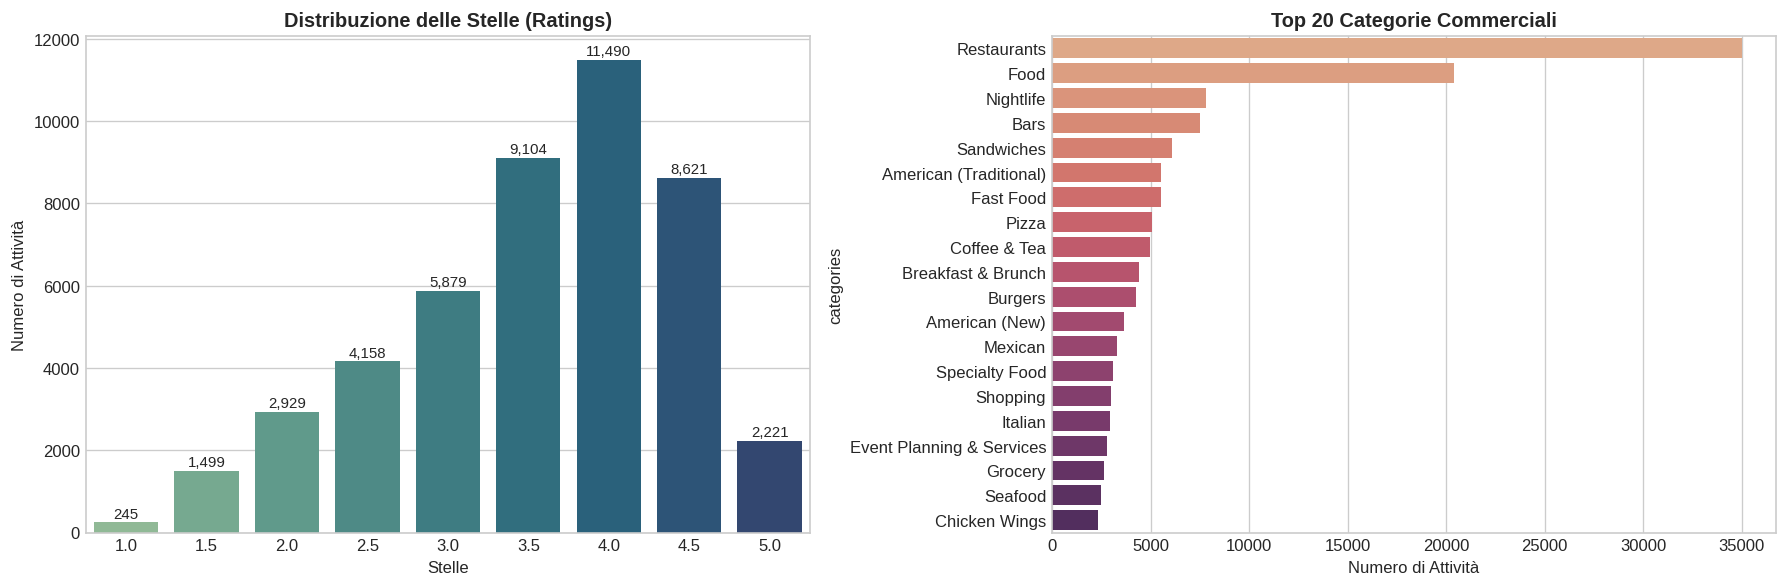

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribuzione stelle
stars_counts = df_businesses['stars'].value_counts().sort_index()
sns.barplot(x=stars_counts.index, y=stars_counts.values, ax=axes[0], palette='crest')
axes[0].set_title("Distribuzione delle Stelle (Ratings)", weight='bold')
axes[0].set_xlabel("Stelle")
axes[0].set_ylabel("Numero di Attività")

for i, val in enumerate(stars_counts.values):
    axes[0].text(i, val + (max(stars_counts.values) * 0.01), f"{val:,d}", ha='center', fontsize=9)

# Top 20 Categorie
categories_series = df_businesses['categories'].dropna().str.split(',').explode().str.strip()
top20_cats = categories_series.value_counts().head(20)

sns.barplot(x=top20_cats.values, y=top20_cats.index, ax=axes[1], palette='flare')
axes[1].set_title("Top 20 Categorie Commerciali", weight='bold')
axes[1].set_xlabel("Numero di Attività")

plt.tight_layout()
plt.show()

## 2. Analisi Città e Disposizione Urbana a Griglia (City Grids)

/tmp/ipykernel_1013/1045743114.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.index, y=top_cities.values, palette='viridis')


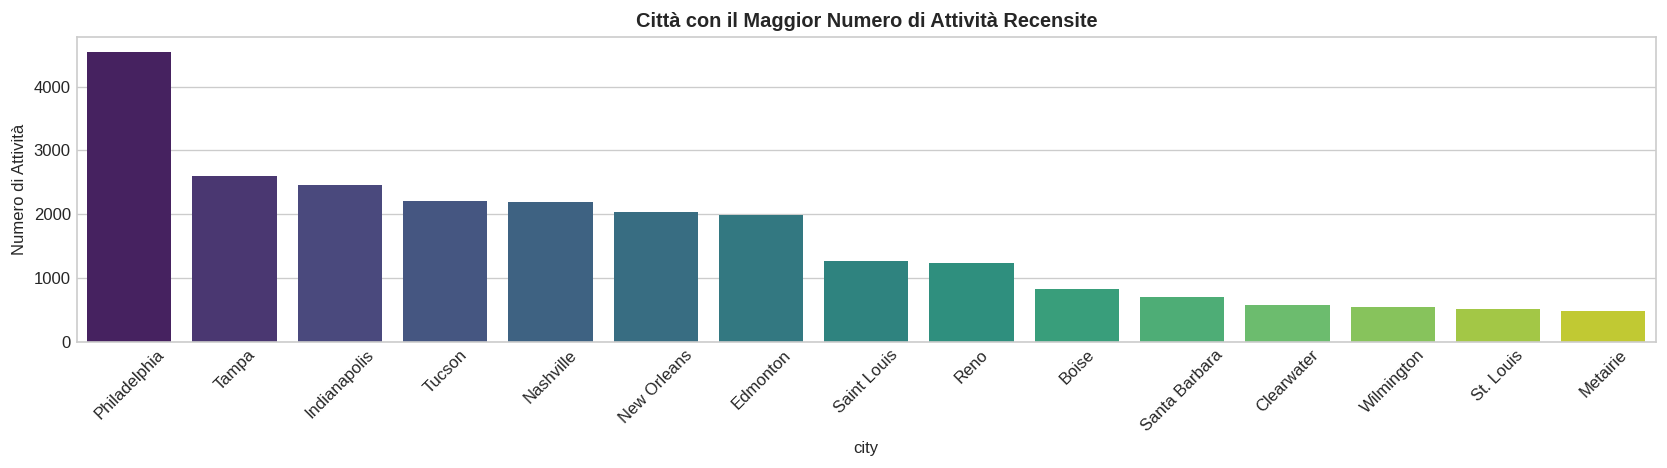

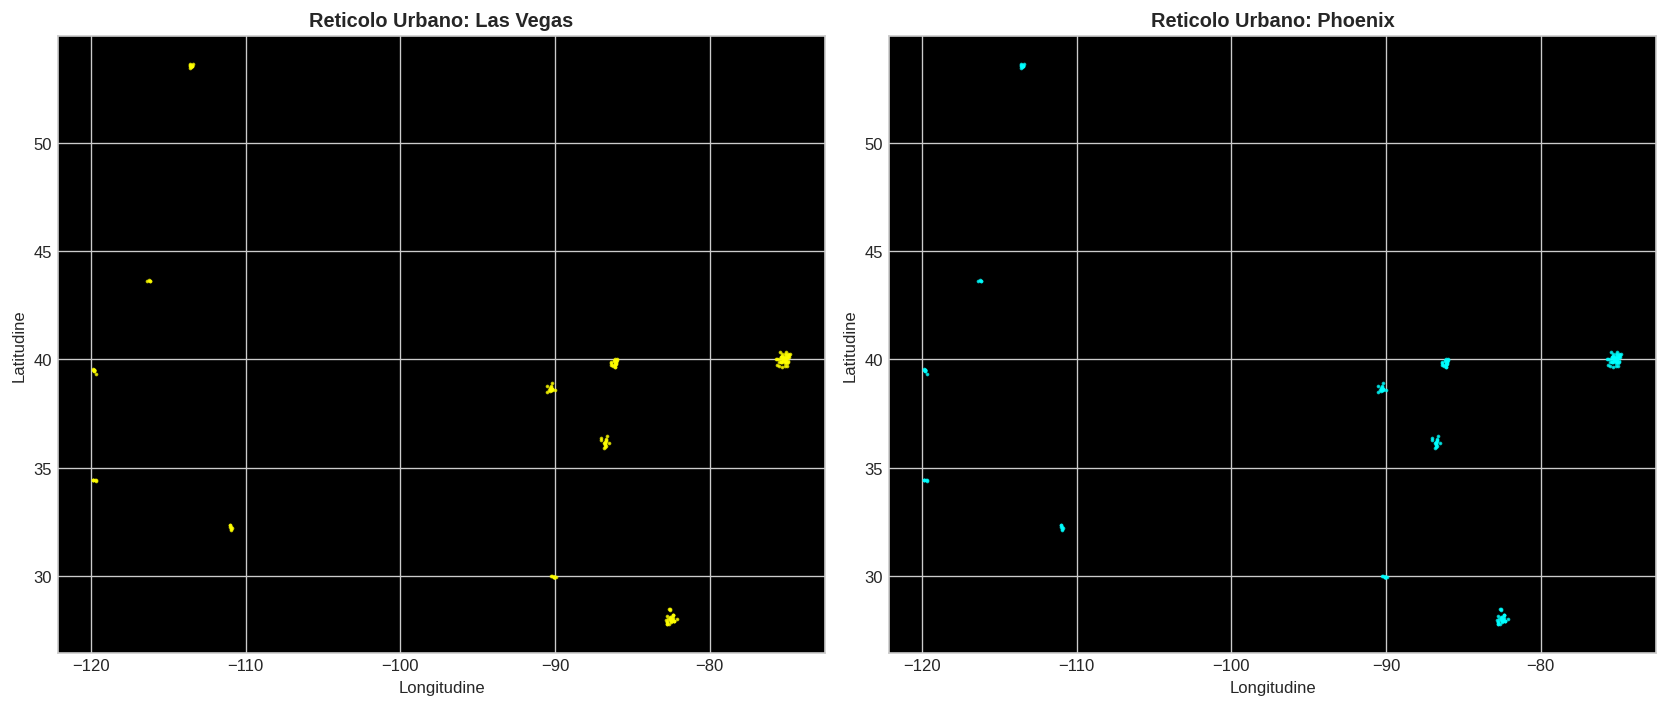

In [5]:
# Città con più attività
plt.figure(figsize=(14, 4))
top_cities = df_businesses['city'].value_counts().head(15)
sns.barplot(x=top_cities.index, y=top_cities.values, palette='viridis')
plt.title("Città con il Maggior Numero di Attività Recensite", weight='bold')
plt.xticks(rotation=45)
plt.ylabel("Numero di Attività")
plt.tight_layout()
plt.show()

# Scatter plot delle coordinate per confrontare i reticoli urbani
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, city, color in zip(axes, ['Las Vegas', 'Phoenix'], ['yellow', 'cyan']):
    subset = df_businesses[df_businesses['city'].str.lower() == city.lower()]
    if len(subset) == 0:
        subset = df_businesses.head(200)
    ax.scatter(subset['longitude'], subset['latitude'], s=1.5, color=color, alpha=0.7)
    ax.set_facecolor('black')
    ax.set_title(f"Reticolo Urbano: {city}", weight='bold')
    ax.set_xlabel("Longitudine")
    ax.set_ylabel("Latitudine")

plt.tight_layout()
plt.show()

## 3. Dinamiche Temporali dei Check-in

weekday,Mon,Tue,Wed,Thu,Fri,Sat,Sun
hour,,,,,,,
0,599,545,661,702,757,1056,1032
1,409,407,509,551,570,924,856
2,288,313,326,343,403,620,573
3,170,169,197,199,267,397,447
4,104,112,112,104,131,279,276
5,63,51,65,65,85,161,217
6,29,29,20,22,46,102,127
7,20,21,21,21,35,60,82
8,11,10,17,12,15,38,50


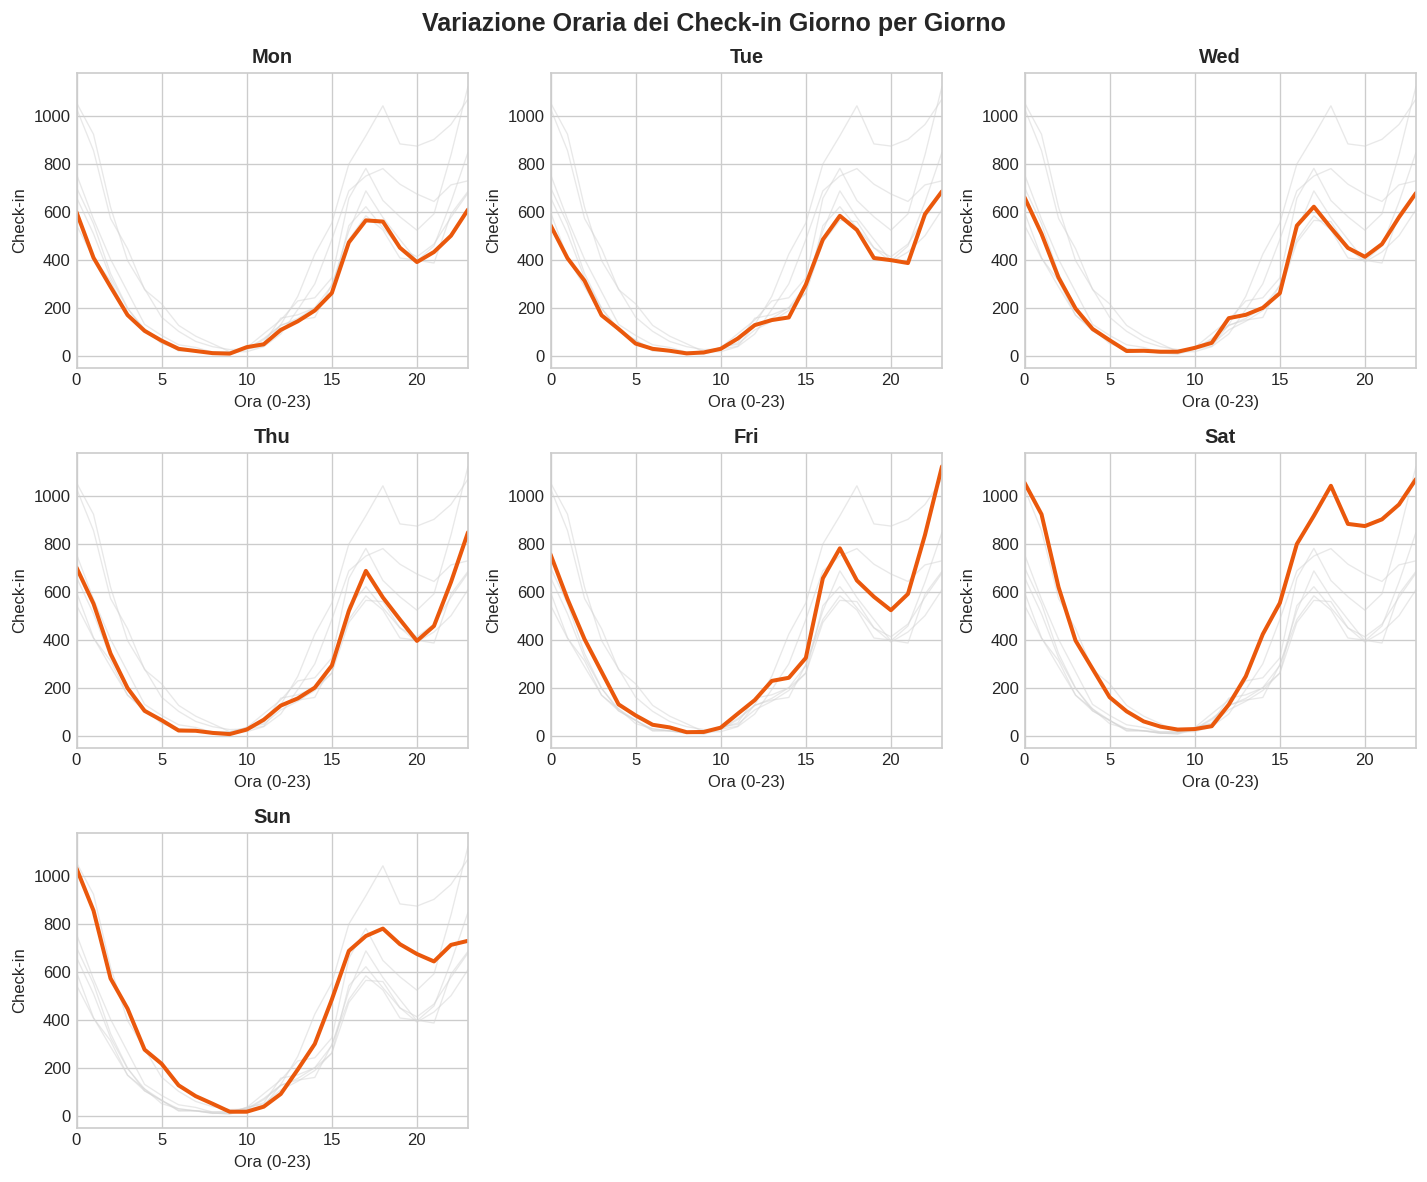

In [6]:
def highlight_max(data, color='yellow'):
    attr = f'background-color: {color}'
    if data.ndim == 1:
        is_max = data == data.max()
        return [attr if v else '' for v in is_max]
    else:
        is_max = data == data.max().max()
        return pd.DataFrame(np.where(is_max, attr, ''), index=data.index, columns=data.columns)

def extract_checkin_times(df):
    records = []
    sample_df = df.sample(min(len(df), 3000), random_state=42) if len(df) > 3000 else df
    for _, row in sample_df.iterrows():
        for d in str(row['date']).split(',')[:25]:
            d = d.strip()
            if len(d) >= 19:
                try:
                    ts = pd.to_datetime(d[:19])
                    records.append((ts.day_name()[:3], ts.hour))
                except Exception:
                    continue
    return pd.DataFrame(records, columns=['weekday', 'hour'])

df_ch_times = extract_checkin_times(df_checkins)
days_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Matrice Pivot Giorno x Ora
ch_pivot = df_ch_times.pivot_table(index='hour', columns='weekday', aggfunc='size', fill_value=0)
ch_pivot = ch_pivot.reindex(columns=[d for d in days_order if d in ch_pivot.columns], fill_value=0)

# Stampa tabella pivot con massimo evidenziato
display(ch_pivot.style.apply(highlight_max, color='darkorange', axis=0))

# Small multiples (griglia 3x3) per l'andamento orario giorno per giorno
fig = plt.figure(figsize=(12, 10))
plt.suptitle("Variazione Oraria dei Check-in Giorno per Giorno", fontsize=15, weight='bold')

for idx, day in enumerate(days_order):
    if day not in ch_pivot.columns:
        continue
    ax = plt.subplot(3, 3, idx + 1)

    # Linee di sfondo grigie per gli altri giorni
    for other_day in ch_pivot.columns:
        ax.plot(ch_pivot.index, ch_pivot[other_day], color='lightgray', linewidth=0.8, alpha=0.5)

    ax.plot(ch_pivot.index, ch_pivot[day], color='#ea580c', linewidth=2.4, label=day)
    ax.set_title(day, weight='bold')
    ax.set_xlim(0, 23)
    ax.set_xlabel("Ora (0-23)")
    ax.set_ylabel("Check-in")

plt.tight_layout()
plt.show()

## 4. User Deep-Dive e Traiettoria del Top Reviewer

2026-09-19 08:35:28 | INFO     | Top 10 Utenti per numero di recensioni:


,count,stars,useful,funny,cool
user_id,,,,,
_BcWyKQL16ndpBdggh2kNA,1474,3.659430,5901,1861,3563
-G7Zkl1wIWBBmD0KRy_sCw,1178,3.615450,27091,14066,21094
fr1Hz2acAb3OaL3l6DyKNg,995,3.972864,11654,3425,9982
Xw7ZjaGfr0WNVt6s_5KZfA,950,4.053684,6451,2582,3855
1HM81n6n4iPIFU5d2Lokhw,938,3.067164,3691,1391,2023
bYENop4BuQepBjM1-BI3fA,906,3.859823,7054,2535,5427
ET8n-r7glWYqZhuR6GcdNw,890,4.051685,11283,3242,7369
wXdbkFZsfDR7utJvbWElyA,820,4.231707,3946,285,2103
pou3BbKsIozfH50rxmnMew,778,4.277635,7528,2710,4807


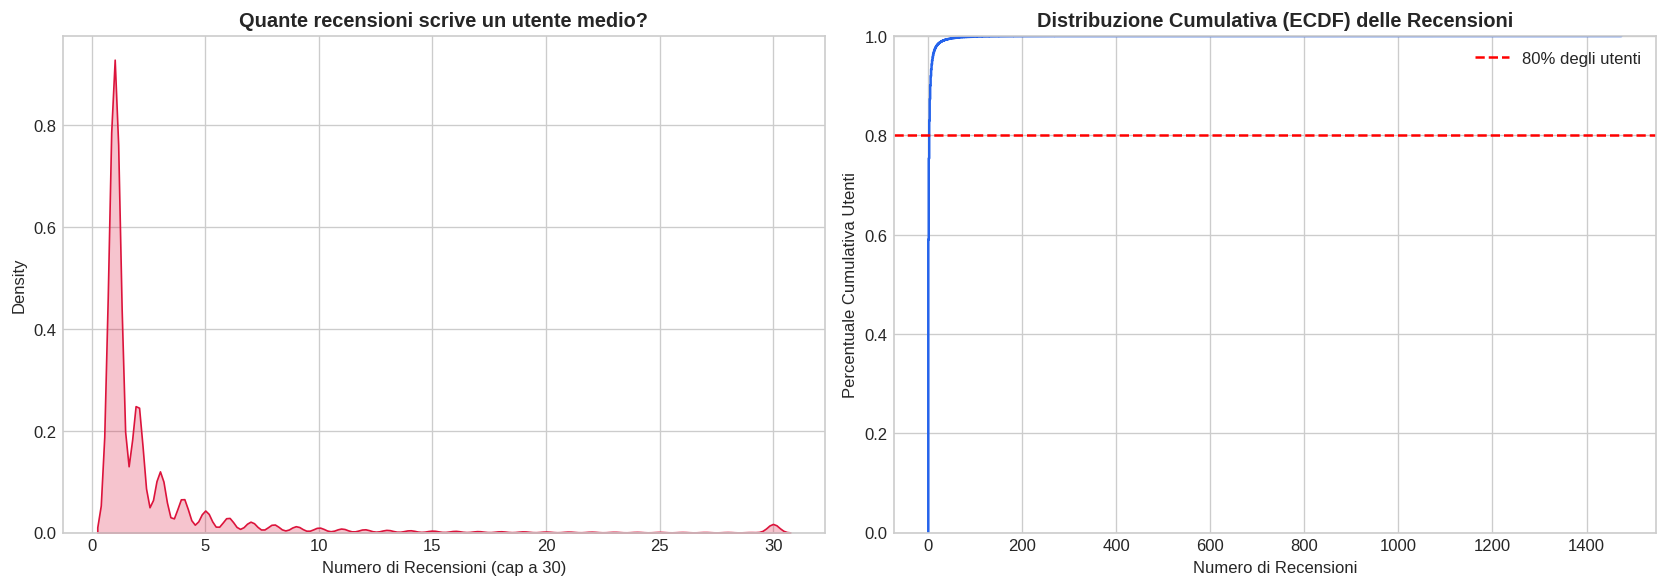

2026-09-19 08:35:40 | SUCCESS  | Mappa traiettoria top reviewer salvata in top_user_trajectory_map.html


In [7]:
# Aggregazioni per utente
user_agg = df_reviews.groupby('user_id').agg({
    'review_id': 'count',
    'stars': 'mean',
    'useful': 'sum',
    'funny': 'sum',
    'cool': 'sum'
}).rename(columns={'review_id': 'count'}).sort_values('count', ascending=False)

logger.info("Top 10 Utenti per numero di recensioni:")
display(user_agg.head(10))

# Distribuzione cumulativa delle recensioni
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

capped_counts = user_agg['count'].clip(upper=30)
sns.kdeplot(capped_counts, fill=True, color='crimson', ax=axes[0])
axes[0].set_title("Quante recensioni scrive un utente medio?", weight='bold')
axes[0].set_xlabel("Numero di Recensioni (cap a 30)")

sns.ecdfplot(user_agg['count'], ax=axes[1], color='#2563eb')
axes[1].set_title("Distribuzione Cumulativa (ECDF) delle Recensioni", weight='bold')
axes[1].set_xlabel("Numero di Recensioni")
axes[1].set_ylabel("Percentuale Cumulativa Utenti")
axes[1].axhline(0.80, color='red', linestyle='--', label="80% degli utenti")
axes[1].legend()

plt.tight_layout()
plt.show()

# Stalking top reviewer: mappa cronologica con HeatMapWithTime
top_user_id = user_agg.index[0]
top_user_revs = df_reviews[df_reviews['user_id'] == top_user_id].copy()
top_user_locs = pd.merge(top_user_revs, df_businesses[['business_id', 'latitude', 'longitude', 'name']], on='business_id')

if len(top_user_locs) > 0 and 'latitude' in top_user_locs.columns:
    top_user_locs['date_str'] = pd.to_datetime(top_user_locs['date']).dt.strftime('%Y-%m')
    dates_sorted = sorted(top_user_locs['date_str'].unique())

    heat_data = []
    for d in dates_sorted:
        sub = top_user_locs[top_user_locs['date_str'] == d]
        heat_data.append(sub[['latitude', 'longitude']].dropna().values.tolist())

    m_user = folium.Map(
        location=[top_user_locs['latitude'].mean(), top_user_locs['longitude'].mean()],
        zoom_start=10,
        tiles="CartoDB Positron"
    )
    if any(len(pts) > 0 for pts in heat_data):
        HeatMapWithTime(heat_data, auto_play=True, max_opacity=0.6, radius=15).add_to(m_user)
        m_user.save(str(DRIVE_DIR / 'top_user_trajectory_map.html'))
        logger.success("Mappa traiettoria top reviewer salvata in top_user_trajectory_map.html")

## 5. Mappe Geospaziali Interattive (Las Vegas e Toronto)

In [8]:
def create_interactive_city_map(city_name, out_file):
    sub = df_businesses[df_businesses['city'].str.lower() == city_name.lower()].copy()
    if len(sub) == 0:
        sub = df_businesses.head(300).copy()

    m = folium.Map(location=[sub['latitude'].mean(), sub['longitude'].mean()], zoom_start=12, tiles='OpenStreetMap')
    cluster = MarkerCluster().add_to(m)

    for _, row in sub.head(250).iterrows():
        color = 'green' if row['stars'] >= 4 else ('orange' if row['stars'] >= 3 else 'red')
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=6,
            color=color,
            fill=True,
            fill_opacity=0.7,
            popup=f"<b>{row['name']}</b><br>Rating: {row['stars']} ⭐<br>Recensioni: {row['review_count']}"
        ).add_to(cluster)

    m.save(str(out_file))
    logger.info(f"Salvata mappa per {city_name} in {out_file.name}")
    return m

create_interactive_city_map('Las Vegas', DRIVE_DIR / 'yelp_vegas_map.html')
create_interactive_city_map('Toronto', DRIVE_DIR / 'yelp_toronto_map.html')

2026-09-19 08:35:40 | INFO     | Salvata mappa per Las Vegas in yelp_vegas_map.html
2026-09-19 08:35:41 | INFO     | Salvata mappa per Toronto in yelp_toronto_map.html


## 6. Social Network Analysis (SNA) con 4 Layout e Community Detection

2026-09-19 08:35:42 | INFO     | Grafo creato: 1,000 nodi, 27,992 archi (densità: 0.05604)
2026-09-19 08:35:42 | INFO     | Comunità identificate nel sottografo: 3


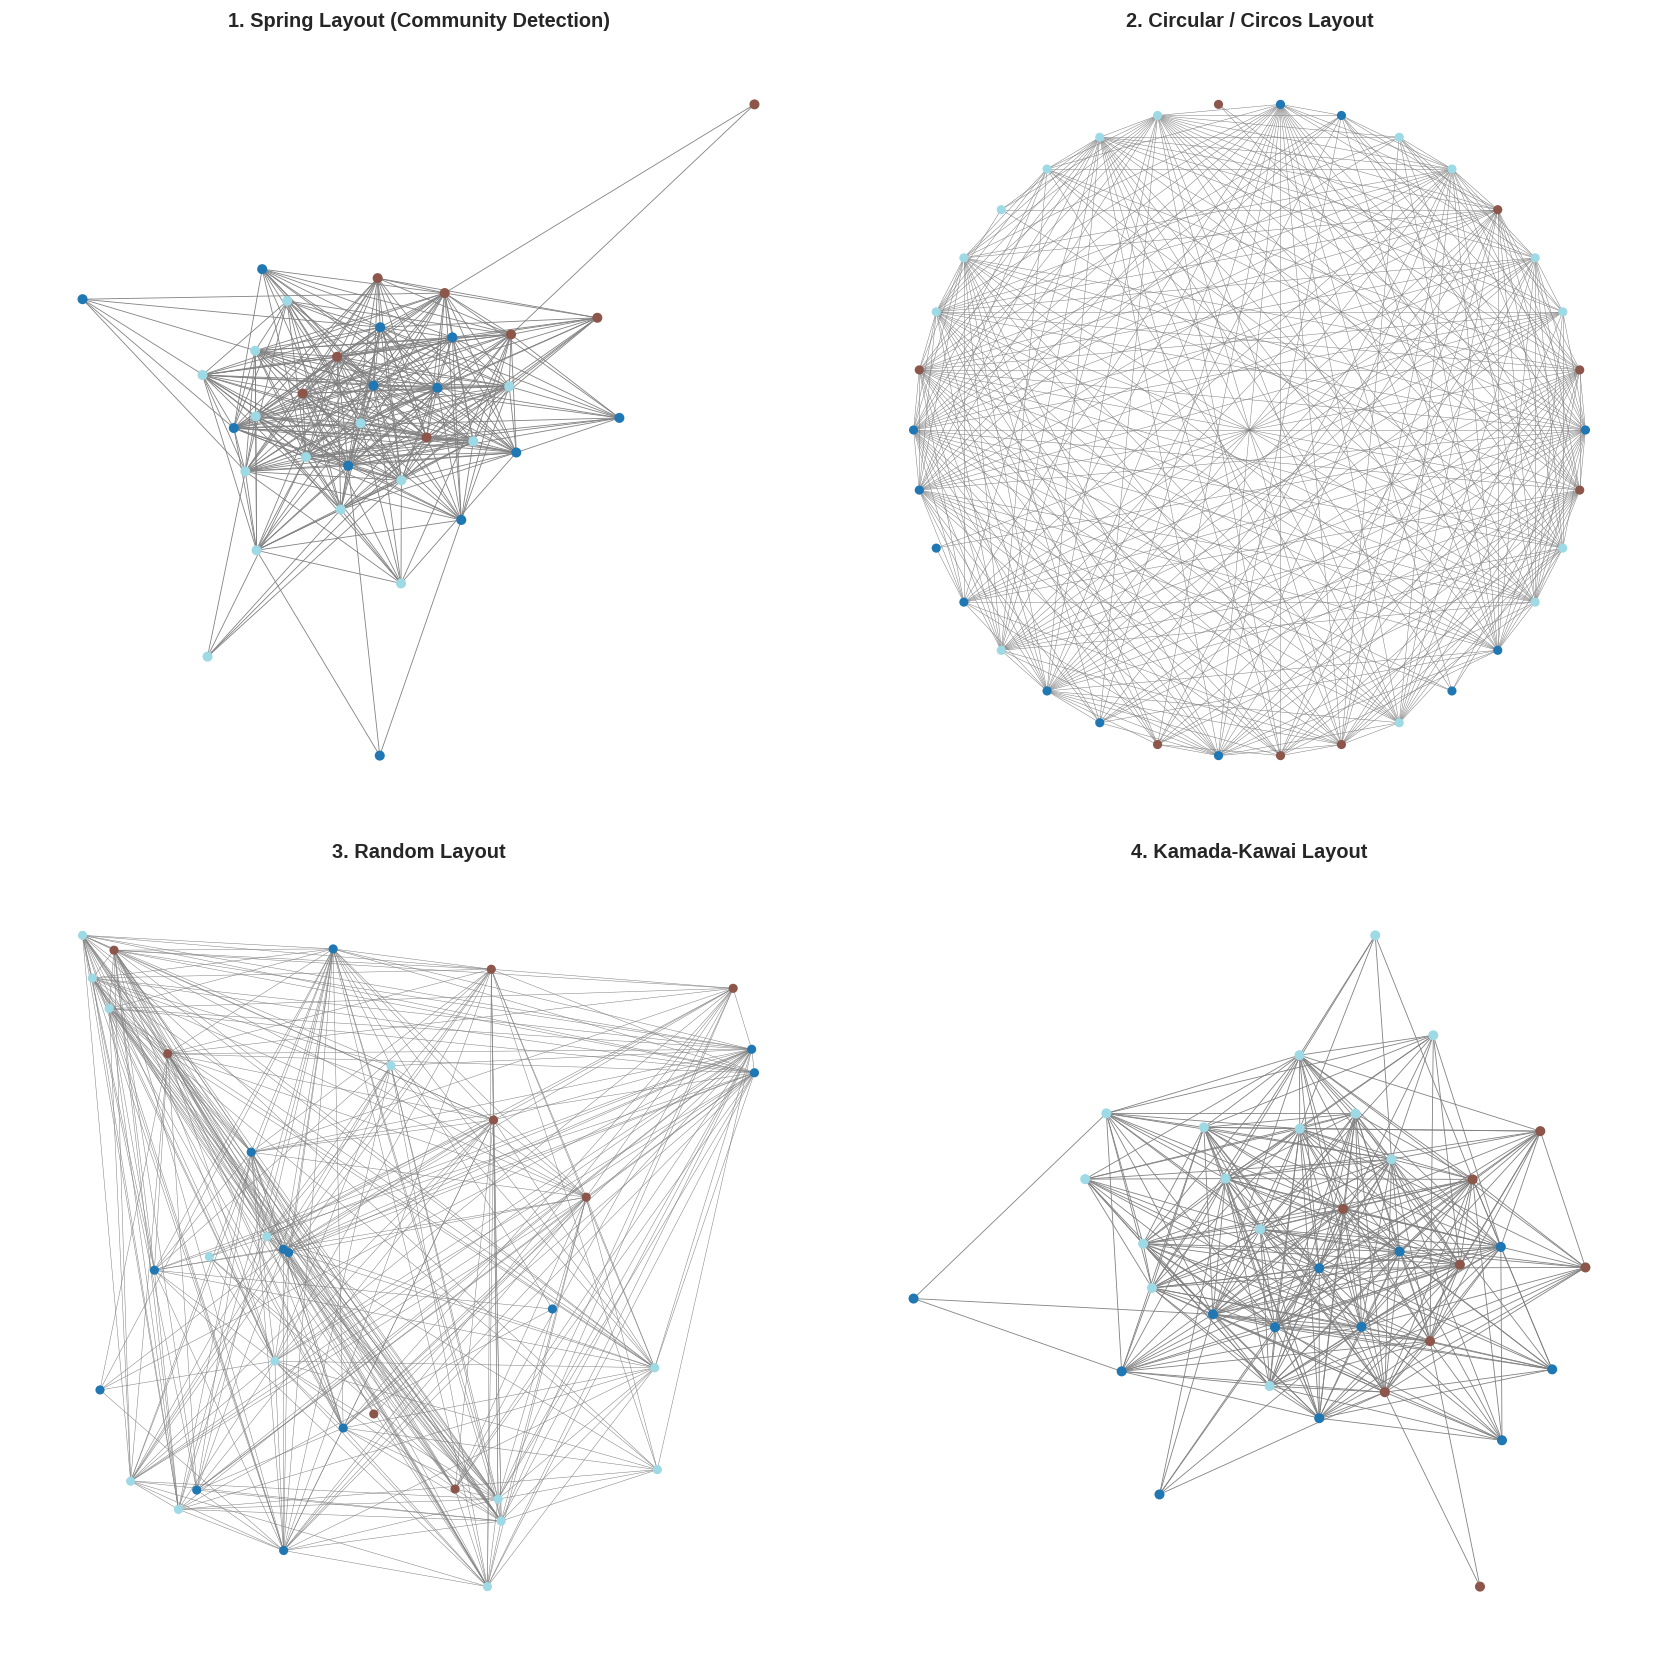

In [9]:
def build_friendship_graph(users_df, sample_limit=1500):
    candidates = users_df.sort_values('review_count', ascending=False).head(sample_limit)
    user_set = set(candidates['user_id'])

    G = nx.Graph()
    for uid in user_set:
        G.add_node(uid)

    for _, row in candidates.iterrows():
        uid = row['user_id']
        friends = str(row.get('friends', '')).split(',')
        for fr in friends:
            fr = fr.strip()
            if fr in user_set and fr != uid:
                G.add_edge(uid, fr)

    return G

G = build_friendship_graph(df_users, sample_limit=1000)
logger.info(f"Grafo creato: {G.number_of_nodes():,d} nodi, {G.number_of_edges():,d} archi (densità: {nx.density(G):.5f})")

# Influencer tramite degree centrality e heapq
deg_cent = nx.degree_centrality(G)
top_influencers = heapq.nlargest(15, deg_cent, key=deg_cent.get)

# Sottografo degli influencer per le visualizzazioni
sub_nodes = set(top_influencers)
for inf in top_influencers:
    sub_nodes.update(list(G.neighbors(inf))[:10])
sub_G = G.subgraph(sub_nodes).copy()
sub_G.remove_nodes_from(list(nx.isolates(sub_G)))

# Community Detection
try:
    import community as community_louvain
    partition = community_louvain.best_partition(sub_G)
except Exception:
    comms = list(nx.algorithms.community.greedy_modularity_communities(sub_G))
    partition = {n: idx for idx, c in enumerate(comms) for n in c}

num_comms = len(set(partition.values())) if partition else 1
logger.info(f"Comunità identificate nel sottografo: {num_comms}")

# 4 Layout Visuali
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
node_colors = [partition.get(n, 0) for n in sub_G.nodes()]

# 1. Spring Layout
pos_spring = nx.spring_layout(sub_G, seed=42, k=0.2)
nx.draw_networkx(sub_G, pos_spring, ax=axes[0, 0], node_size=25, node_color=node_colors, cmap='tab20', with_labels=False, edge_color='gray', width=0.5)
axes[0, 0].set_title("1. Spring Layout (Community Detection)", weight='bold')
axes[0, 0].axis('off')

# 2. Circular / Circos Layout
pos_circ = nx.circular_layout(sub_G)
nx.draw_networkx(sub_G, pos_circ, ax=axes[0, 1], node_size=20, node_color=node_colors, cmap='tab20', with_labels=False, edge_color='gray', width=0.3)
axes[0, 1].set_title("2. Circular / Circos Layout", weight='bold')
axes[0, 1].axis('off')

# 3. Random Layout
pos_rand = nx.random_layout(sub_G, seed=42)
nx.draw_networkx(sub_G, pos_rand, ax=axes[1, 0], node_size=20, node_color=node_colors, cmap='tab20', with_labels=False, edge_color='gray', width=0.3)
axes[1, 0].set_title("3. Random Layout", weight='bold')
axes[1, 0].axis('off')

# 4. Kamada-Kawai Layout
try:
    pos_kk = nx.kamada_kawai_layout(sub_G)
    nx.draw_networkx(sub_G, pos_kk, ax=axes[1, 1], node_size=25, node_color=node_colors, cmap='tab20', with_labels=False, edge_color='gray', width=0.5)
    axes[1, 1].set_title("4. Kamada-Kawai Layout", weight='bold')
except Exception:
    axes[1, 1].set_title("4. Kamada-Kawai Layout (Non calcolabile)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 7. Suggerimenti di Amicizia ed Esportazione Metriche

In [10]:
# Modulo di suggerimento amicizie (vicini comuni non ancora connessi)
def suggest_friends(graph, user_id, top_k=3):
    if user_id not in graph:
        return []
    user_friends = set(graph.neighbors(user_id))
    suggestions = {}
    for friend in user_friends:
        for fof in graph.neighbors(friend):
            if fof != user_id and fof not in user_friends:
                suggestions[fof] = suggestions.get(fof, 0) + 1
    return sorted(suggestions.items(), key=lambda x: x[1], reverse=True)[:top_k]

sample_influencer = top_influencers[0]
recs = suggest_friends(G, sample_influencer, top_k=3)
logger.info(f"Suggerimenti di amicizia per l'influencer {sample_influencer}: {recs}")

# Esportazione metriche strutturate
network_metrics = {
    'num_nodes': int(G.number_of_nodes()),
    'num_edges': int(G.number_of_edges()),
    'density': float(nx.density(G)),
    'num_communities': int(num_comms),
    'top_influencers': [{'user_id': uid, 'degree_centrality': float(deg_cent[uid])} for uid in top_influencers[:10]]
}

with open(DRIVE_DIR / 'network_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(network_metrics, f, indent=2)

logger.success("Metriche di rete salvate con successo in network_metrics.json")

2026-09-19 08:35:43 | INFO     | Suggerimenti di amicizia per l'influencer Oi1qbcz2m2SnwUeztGYcnQ: [('8lEywHSvti2UjFP8ODbnHg', 228), ('t4RLfHlTiaC8zy15fnXG3w', 218), ('--2vR0DIsmQ6WfcSzKWigw', 159)]
2026-09-19 08:35:43 | SUCCESS  | Metriche di rete salvate con successo in network_metrics.json
